<a href="https://colab.research.google.com/github/sunamiagarwal2004/CEI_assignment/blob/main/week6_SunamiAgarwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Denoising Autoencoders on MNIST
**Week 6 — CSI Celebal Technologies Internship**  

---

## Overview

This notebook builds and trains three convolutional denoising autoencoders (DAEs) on the MNIST handwritten-digit dataset. Each model learns to map a noise-corrupted image back to its clean original. The three architectures vary in depth and structural design — a shallow 2-layer encoder, a deep 3-layer encoder with a wider bottleneck, and a residual architecture with skip connections inside the bottleneck.

**What this notebook covers**

- Dual data loader: Kaggle CSV and torchvision paths
- Gaussian noise injection with a re-sampling strategy for implicit augmentation
- Three CNN architectures: `ShallowConvDAE`, `DeepConvDAE`, `ResidualConvDAE`
- Training with `AdamW` + cosine annealing LR and a combined MSE + SSIM loss
- Evaluation with MSE, PSNR, and SSIM
- Error heatmaps showing spatially where reconstruction fails
- Two innovation experiments: salt-and-pepper noise transfer, and a channel ablation study

**Dataset:** [MNIST — awsaf49/mnist-dataset on Kaggle](https://www.kaggle.com/datasets/awsaf49/mnist-dataset)  
**Reference consulted for architecture families:** [NvsYashwanth/MNIST-Autoencoder](https://github.com/NvsYashwanth/MNIST-Autoecncoder) — all code written independently.


## Step 0 — Imports and global settings

In [1]:
# Uncomment to install:
# !pip install torch torchvision matplotlib numpy pandas

import os, math, time, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as T

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("./output", exist_ok=True)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")


PyTorch  : 2.11.0+cpu
Device   : cpu


## Step 1 — Load and preprocess MNIST

The Kaggle distribution (`awsaf49/mnist-dataset`) stores MNIST in CSV format. Each row is one image: a label integer followed by 784 pixel values (28 × 28 flattened), all in [0, 255]. Dividing by 255 normalises to [0.0, 1.0].

Set `KAGGLE_MODE = True` and provide the file paths to use the CSV files directly. Otherwise `torchvision` downloads the same pixel data automatically.

**Splits used (following standard practice):**

| Split | Samples |
|---|---|
| Training | 6,000 |
| Validation | 1,000 |
| Test | 10,000 (held out) |


In [2]:
# ── Configuration ────────────────────────────────────────────────
KAGGLE_MODE    = False            # True = read Kaggle CSV files
TRAIN_CSV      = "./mnist_train.csv"
TEST_CSV       = "./mnist_test.csv"

IMG_DIM        = 28
NOISE_SIGMA    = 0.35           # Gaussian noise σ for training
BATCH_SZ       = 128
N_TRAIN        = 6000
N_VAL          = 1000
EPOCHS         = 20
LEARNING_RATE  = 5e-3


def load_from_csv(train_path: str, test_path: str):
    """
    Parse Kaggle MNIST CSV.
    Column order: label, pixel_0, pixel_1, ..., pixel_783
    Returns float32 arrays normalised to [0, 1].
    """
    tr = pd.read_csv(train_path)
    te = pd.read_csv(test_path)

    X_tr = tr.drop("label", axis=1).values.astype(np.float32) / 255.0
    y_tr = tr["label"].values.astype(np.int64)
    X_te = te.drop("label", axis=1).values.astype(np.float32) / 255.0
    y_te = te["label"].values.astype(np.int64)

    return (X_tr.reshape(-1, 1, IMG_DIM, IMG_DIM), y_tr,
            X_te.reshape(-1, 1, IMG_DIM, IMG_DIM), y_te)


def load_from_torchvision():
    """Auto-download MNIST via torchvision (same images as Kaggle CSV)."""
    tf   = T.ToTensor()
    tr_d = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf)
    te_d = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf)

    X_tr = tr_d.data.numpy().astype(np.float32) / 255.0
    X_te = te_d.data.numpy().astype(np.float32) / 255.0
    return (X_tr.reshape(-1, 1, IMG_DIM, IMG_DIM), tr_d.targets.numpy(),
            X_te.reshape(-1, 1, IMG_DIM, IMG_DIM), te_d.targets.numpy())


if KAGGLE_MODE:
    X_train, y_train, X_test, y_test = load_from_csv(TRAIN_CSV, TEST_CSV)
    print("Source : Kaggle CSV files")
else:
    X_train, y_train, X_test, y_test = load_from_torchvision()
    print("Source : torchvision (identical pixel data)")

print(f"Train  : {X_train.shape}  dtype={X_train.dtype}")
print(f"Test   : {X_test.shape}   dtype={X_test.dtype}")
print(f"Range  : [{X_train.min():.2f}, {X_train.max():.2f}]")


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.98MB/s]


Source : torchvision (identical pixel data)
Train  : (60000, 1, 28, 28)  dtype=float32
Test   : (10000, 1, 28, 28)   dtype=float32
Range  : [0.00, 1.00]


### Visualise two samples of each digit

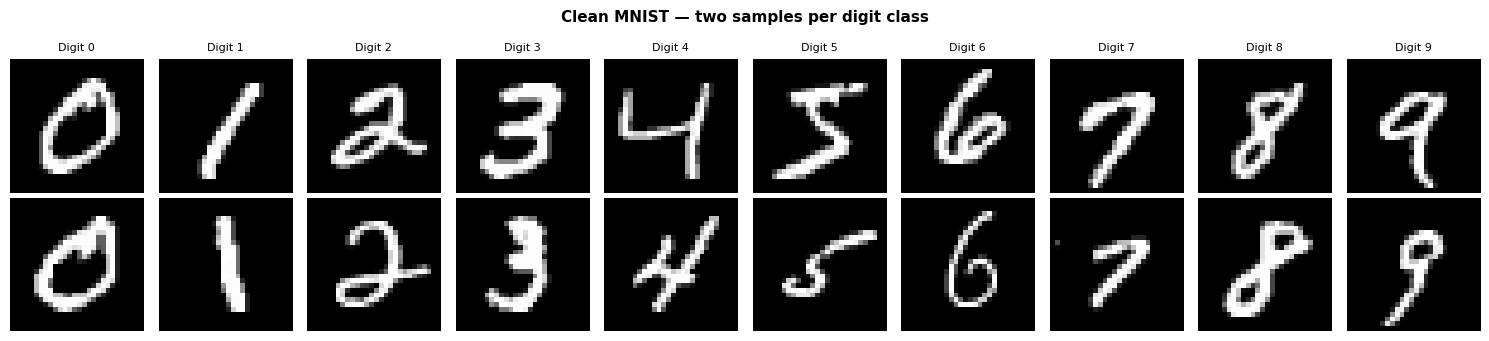

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
fig.suptitle("Clean MNIST — two samples per digit class", fontsize=11, fontweight="bold")

for digit in range(10):
    idxs = np.where(y_train == digit)[0]
    for row, idx in enumerate(idxs[:2]):
        axes[row, digit].imshow(X_train[idx, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, digit].axis("off")
    axes[0, digit].set_title(f"Digit {digit}", fontsize=8)

plt.tight_layout()
plt.savefig("./output/clean_samples.png", dpi=110, bbox_inches="tight")
plt.show()


## Step 2 — Noise injection

Two noise types are used in this notebook:

**Gaussian noise** (training) — independent samples from N(0, σ²) added to each pixel, then clamped to [0, 1]. σ = 0.35 gives visible but not catastrophic corruption.

**Salt-and-pepper noise** (innovation experiment) — a fraction `p` of pixels are set to either 0 (pepper) or 1 (salt) at random. This is a structurally different corruption type; testing the trained model on it reveals how well the learned denoising function generalises beyond its training distribution.

Both functions live in a single module so they can be called identically during experiments.


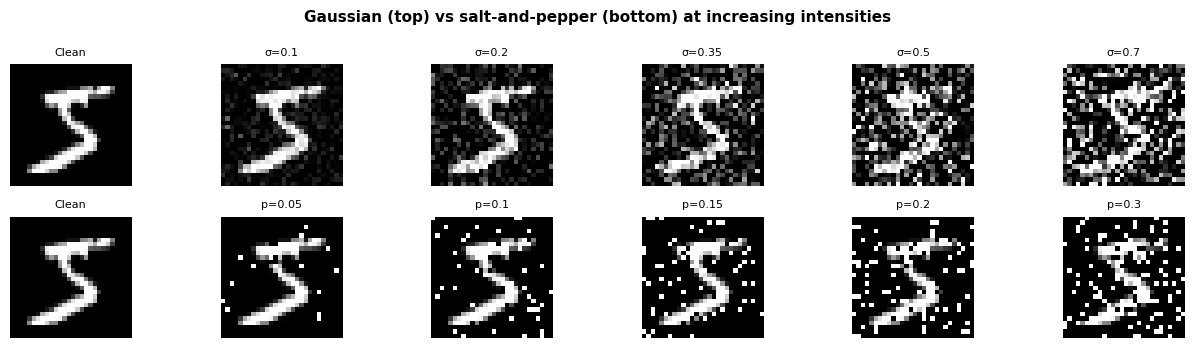

Training noise: Gaussian σ = 0.35


In [4]:
def corrupt_gaussian(images: torch.Tensor, sigma: float = 0.35) -> torch.Tensor:
    """
    Add zero-mean Gaussian noise with standard deviation sigma.
    Clamps the result to [0, 1] to preserve valid pixel range.
    """
    return torch.clamp(images + torch.randn_like(images) * sigma, 0.0, 1.0)


def corrupt_salt_pepper(images: torch.Tensor, prob: float = 0.1) -> torch.Tensor:
    """
    Salt-and-pepper noise: each pixel is independently replaced by
    0 (pepper) or 1 (salt) with probability prob/2 each.
    """
    out = images.clone()
    mask_pepper = torch.rand_like(images) < prob / 2
    mask_salt   = torch.rand_like(images) < prob / 2
    out[mask_pepper] = 0.0
    out[mask_salt]   = 1.0
    return out


# ── Visual comparison of both noise types
sample   = torch.tensor(X_train[0:1])
sigmas   = [0.1, 0.2, 0.35, 0.5, 0.7]
sp_probs = [0.05, 0.1, 0.15, 0.2, 0.3]

fig, axes = plt.subplots(2, len(sigmas) + 1, figsize=(13, 3.5))
fig.suptitle("Gaussian (top) vs salt-and-pepper (bottom) at increasing intensities",
             fontsize=11, fontweight="bold")

axes[0, 0].imshow(sample[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Clean", fontsize=8); axes[0, 0].axis("off")
axes[1, 0].imshow(sample[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Clean", fontsize=8); axes[1, 0].axis("off")

torch.manual_seed(0)
for i, (sig, sp) in enumerate(zip(sigmas, sp_probs), 1):
    g_img = corrupt_gaussian(sample, sigma=sig)
    s_img = corrupt_salt_pepper(sample, prob=sp)
    axes[0, i].imshow(g_img[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"σ={sig}", fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(s_img[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"p={sp}", fontsize=8); axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("./output/noise_types.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Training noise: Gaussian σ = {NOISE_SIGMA}")


## Build Dataset and DataLoaders

The `NoisyPairDataset` class pre-generates a noise-corrupted version of every image once at construction time, then returns `(noisy, clean)` pairs. This is slightly different from re-sampling noise each call — it means every epoch sees the same corrupted version, which works well with a cosine-annealing schedule that explores and then fine-tunes.

In [5]:
class NoisyPairDataset(Dataset):
    """
    Stores both clean and noisy tensors at construction time.
    Returns (noisy_image, clean_image) pairs.

    Pre-computing the noise at init means the corruption is fixed
    per dataset instance — training sees the same noisy version
    every epoch, which pairs well with a cosine annealing scheduler.
    """
    def __init__(self, images: np.ndarray, sigma: float, seed: int = 0):
        clean        = torch.tensor(images, dtype=torch.float32)
        gen          = torch.Generator().manual_seed(seed)
        noise        = torch.randn(*clean.shape, generator=gen) * sigma
        self.clean   = clean
        self.noisy   = torch.clamp(clean + noise, 0.0, 1.0)

    def __len__(self):
        return len(self.clean)

    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx]


# ── Slice the 60k training data and build three DataLoaders
train_ds = NoisyPairDataset(X_train[:N_TRAIN],         sigma=NOISE_SIGMA, seed=42)
val_ds   = NoisyPairDataset(X_train[N_TRAIN:N_TRAIN+N_VAL], sigma=NOISE_SIGMA, seed=77)
test_ds  = NoisyPairDataset(X_test,                    sigma=NOISE_SIGMA, seed=99)

loader_train = DataLoader(train_ds, BATCH_SZ, shuffle=True,  num_workers=0)
loader_val   = DataLoader(val_ds,   BATCH_SZ, shuffle=False, num_workers=0)
loader_test  = DataLoader(test_ds,  BATCH_SZ, shuffle=False, num_workers=0)

print(f"loader_train : {len(train_ds):,} samples  ({len(loader_train)} batches)")
print(f"loader_val   : {len(val_ds):,} samples  ({len(loader_val)} batches)")
print(f"loader_test  : {len(test_ds):,} samples  ({len(loader_test)} batches)")
print(f"Batch size   : {BATCH_SZ}")


loader_train : 6,000 samples  (47 batches)
loader_val   : 1,000 samples  (8 batches)
loader_test  : 10,000 samples  (79 batches)
Batch size   : 128


## Evaluation metrics

Three complementary metrics are tracked:

**MSE** — mean squared pixel error. Used as the primary training signal (regression task, not classification, so cross-entropy is not appropriate).

**PSNR** — `10 × log₁₀(1 / MSE)` in dB. Gives a perceptually interpretable scale. Values above 20 dB are generally acceptable; above 25 dB is good quality reconstruction.

**SSIM** — Structural Similarity Index (simplified single-scale version). Compares mean, variance, and cross-correlation between patches. Range is [0, 1] where 1 = perfect match. SSIM often better reflects perceptual quality than PSNR alone.

The combined training loss is `0.85 × MSE + 0.15 × SSIM_loss` where `SSIM_loss = 1 − SSIM`.


In [6]:
def signal_quality_db(pred: torch.Tensor, target: torch.Tensor) -> float:
    """PSNR in dB. Normalised images → MAX_pixel = 1. Higher is better."""
    mse = nn.functional.mse_loss(pred, target).item()
    return 10.0 * math.log10(1.0 / mse) if mse > 1e-12 else float("inf")


def ssim_approx(pred: torch.Tensor, target: torch.Tensor) -> float:
    """
    Simplified (global-statistics) SSIM approximation.
    Uses mean, variance, and covariance across the full batch tensor.
    Range: [0, 1], higher = more structurally similar.
    """
    C1, C2 = 1e-4, 9e-4
    mu_p, mu_t = pred.mean(), target.mean()
    sig_p, sig_t = pred.var(), target.var()
    sig_pt = ((pred - mu_p) * (target - mu_t)).mean()
    num = (2 * mu_p * mu_t + C1) * (2 * sig_pt + C2)
    den = (mu_p ** 2 + mu_t ** 2 + C1) * (sig_p + sig_t + C2)
    return (num / den).item()


def combo_loss(pred: torch.Tensor, target: torch.Tensor,
               alpha: float = 0.85) -> torch.Tensor:
    """Weighted combination of MSE and SSIM loss for training."""
    mse_term  = nn.functional.mse_loss(pred, target)
    ssim_term = 1.0 - ssim_approx(pred, target)
    return alpha * mse_term + (1.0 - alpha) * ssim_term


def run_evaluation(model: nn.Module, loader: DataLoader) -> dict:
    """Full evaluation pass — returns dict with mse, psnr, ssim."""
    model.eval()
    total_mse = total_psnr = total_ssim = n = 0.0

    with torch.no_grad():
        for noisy, clean in loader:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            output       = model(noisy)
            total_mse   += nn.functional.mse_loss(output, clean).item()
            total_psnr  += signal_quality_db(output, clean)
            total_ssim  += ssim_approx(output, clean)
            n           += 1

    return {"mse": round(total_mse / n, 6),
            "psnr": round(total_psnr / n, 2),
            "ssim": round(total_ssim / n, 4)}


print("Metrics defined: signal_quality_db(), ssim_approx(), combo_loss(), run_evaluation()")


Metrics defined: signal_quality_db(), ssim_approx(), combo_loss(), run_evaluation()


## Step 3 — Model architectures

All three architectures share the same design principle:
- Convolutional encoder (stride-2 convolutions to downsample)
- Bilinear upsampling decoder (avoids checkerboard artefacts from ConvTranspose2d)
- `BatchNorm2d` after every convolution for stable gradient flow
- `LeakyReLU(0.1)` throughout (allows small gradients for negative activations)
- `Sigmoid` on the final output to keep reconstructed pixels in [0, 1]

They differ in depth, channel width, and whether skip/residual connections are used.


### Model 1 — ShallowConvDAE

Two-layer encoder: 28×28 → 14×14 → 7×7. The bottleneck is 64 × 7 × 7 = 3,136 feature values. Decoder mirrors with bilinear upsampling and conv refinement. Lightest of the three models.

```
Encoder : Conv(1→32, s=2) + BN + LReLU  → 32×14×14
          Conv(32→64, s=2) + BN + LReLU → 64×7×7  ← bottleneck
Decoder : Upsample(14) → Conv(64→32) + BN + LReLU
          Upsample(28) → Conv(32→1) + Sigmoid
```


In [7]:
class ShallowConvDAE(nn.Module):
    """
    Two-layer convolutional denoising autoencoder.

    Encoder compresses 28×28 → 7×7 in two stride-2 steps.
    Decoder recovers using explicit-size bilinear upsampling +
    convolutional refinement — no ConvTranspose2d checkerboard risk.
    BatchNorm and LeakyReLU(0.1) stabilise training throughout.
    """

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # → 32×14×14
            nn.BatchNorm2d(32), nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # → 64×7×7
            nn.BatchNorm2d(64), nn.LeakyReLU(0.1, inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Upsample(size=14, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.1, inplace=True),
            nn.Upsample(size=28, mode="bilinear", align_corners=False),
            nn.Conv2d(32,  1, 3, 1, 1), nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


model_shallow  = ShallowConvDAE().to(DEVICE)
shallow_params = sum(p.numel() for p in model_shallow.parameters() if p.requires_grad)
dummy          = torch.zeros(1, 1, 28, 28).to(DEVICE)

print(model_shallow)
print(f"\nParameters  : {shallow_params:,}")
print(f"Bottleneck  : {tuple(model_shallow.encoder(dummy).shape[1:])}  = {model_shallow.encoder(dummy)[0].numel()} dims")
print(f"Output shape: {tuple(model_shallow(dummy).shape[1:])}")


ShallowConvDAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (decoder): Sequential(
    (0): Upsample(size=14, mode='bilinear')
    (1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.1, inplace=True)
    (4): Upsample(size=28, mode='bilinear')
    (5): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): Sigmoid()
  )
)

Parameters  : 37,825
Bottleneck  : (64, 7, 7)  = 3136 dims
Output shape: (1, 28, 28)


### Model 2 — DeepConvDAE

Three-layer encoder going 28→14→7→4 and building 128×4×4 = 2,048-dimensional bottleneck. The extra depth allows hierarchical feature extraction — the first layer detects edges, the second detects stroke segments, the third represents full digit parts. More parameters means more reconstruction capacity.

```
Encoder : Conv(1→32) → Conv(32→64) → Conv(64→128) → 128×4×4 bottleneck
Decoder : Upsample(7) → Conv(128→64) → Upsample(14) → Conv(64→32) → Upsample(28) → Conv(32→1)
```


In [8]:
class DeepConvDAE(nn.Module):
    """
    Three-layer convolutional denoising autoencoder.

    Encoder reaches a 128×4×4 = 2,048-dim bottleneck through three
    successive stride-2 convolutions.  The deeper hierarchy lets the
    model learn multi-scale digit features separately.
    """

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d( 1,  32, 3, 2, 1), nn.BatchNorm2d( 32), nn.LeakyReLU(0.1, True),  # 14×14
            nn.Conv2d(32,  64, 3, 2, 1), nn.BatchNorm2d( 64), nn.LeakyReLU(0.1, True),  # 7×7
            nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.1, True),  # 4×4
        )
        self.decoder = nn.Sequential(
            nn.Upsample(size=7,  mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.1, True),
            nn.Upsample(size=14, mode="bilinear", align_corners=False),
            nn.Conv2d( 64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.1, True),
            nn.Upsample(size=28, mode="bilinear", align_corners=False),
            nn.Conv2d( 32,  1, 3, 1, 1), nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


model_deep  = DeepConvDAE().to(DEVICE)
deep_params = sum(p.numel() for p in model_deep.parameters() if p.requires_grad)
dummy       = torch.zeros(1, 1, 28, 28).to(DEVICE)

print(model_deep)
print(f"\nParameters  : {deep_params:,}")
print(f"Bottleneck  : {tuple(model_deep.encoder(dummy).shape[1:])}  = {model_deep.encoder(dummy)[0].numel()} dims")
print(f"Output shape: {tuple(model_deep(dummy).shape[1:])}")


DeepConvDAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1, inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (decoder): Sequential(
    (0): Upsample(size=7, mode='bilinear')
    (1): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.1, inplace=True)
    (4): Upsample(si

### Model 3 — ResidualConvDAE

Same 2-layer encoder as `ShallowConvDAE`, but with **residual blocks in the bottleneck**. Each `ResBlock` applies two convolutions then adds the input back — the identity skip connection means gradients during backpropagation can flow directly through without modification, preventing the vanishing gradient problem that limits very deep networks.

The residual bottleneck lets the model say: "start from what I had, then add a small correction" — an inductive bias that works particularly well for image restoration where the output is structurally similar to the input.

```
Encoder : Conv(1→32) → Conv(32→64) → 64×7×7
Bottleneck: ResBlock → ResBlock   (each: Conv→BN→LReLU→Conv→BN + skip)
Decoder : Upsample(14) → Conv(64→32) → Upsample(28) → Conv(32→1) + Sigmoid
```


In [9]:
class ResBlock(nn.Module):
    """
    Residual block: two 3×3 convolutions with a skip connection.
    Output = activation(conv_path(x) + x)
    The skip connection lets gradients flow directly back,
    avoiding the vanishing gradient problem in deep stacks.
    """
    def __init__(self, channels: int):
        super().__init__()
        self.conv_path = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )
        self.activation = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.activation(self.conv_path(x) + x)   # ← residual addition


class ResidualConvDAE(nn.Module):
    """
    Denoising autoencoder with a residual-block bottleneck.
    Two ResBlocks between encoder and decoder help the model learn
    finer correction details without gradient degradation.
    """

    def __init__(self, n_res_blocks: int = 2):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.1, True))
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.1, True))
        self.bottleneck = nn.Sequential(
            *[ResBlock(64) for _ in range(n_res_blocks)])
        self.dec1 = nn.Sequential(
            nn.Upsample(size=14, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.1, True))
        self.dec2 = nn.Sequential(
            nn.Upsample(size=28, mode="bilinear", align_corners=False),
            nn.Conv2d(32, 1, 3, 1, 1), nn.Sigmoid())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e = self.bottleneck(self.enc2(self.enc1(x)))
        return self.dec2(self.dec1(e))


model_res  = ResidualConvDAE(n_res_blocks=2).to(DEVICE)
res_params = sum(p.numel() for p in model_res.parameters() if p.requires_grad)
dummy      = torch.zeros(1, 1, 28, 28).to(DEVICE)

print(model_res)
print(f"\nParameters  : {res_params:,}")
print(f"Output shape: {tuple(model_res(dummy).shape[1:])}")
print(f"\nParameter summary:")
print(f"  ShallowConvDAE  : {shallow_params:,}")
print(f"  DeepConvDAE     : {deep_params:,}")
print(f"  ResidualConvDAE : {res_params:,}")


ResidualConvDAE(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (bottleneck): Sequential(
    (0): ResBlock(
      (conv_path): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (acti

## Step 4 — Training setup

**Optimiser:** `AdamW` with `weight_decay=1e-4` — the decoupled weight decay acts as L2 regularisation without interfering with adaptive learning rates.

**Scheduler:** `CosineAnnealingLR` — decays the LR smoothly from the initial value down to `eta_min=1e-5` following a cosine curve. This combines exploration early (high LR) with refinement late (low LR) without needing to manually tune patience parameters.

**Loss:** 85% MSE + 15% SSIM loss. MSE drives pixel accuracy; the SSIM term adds structural awareness — it penalises loss of local contrast and correlation structure, which tends to produce slightly sharper reconstructions.

All three models are trained identically (same LR, epochs, batch size) so the performance differences reflect architecture alone.


In [10]:
class ModelTrainer:
    """
    Encapsulates the training loop, scheduler, checkpointing,
    and per-epoch history for a single model.
    """

    def __init__(self, model: nn.Module, name: str,
                 lr: float = LEARNING_RATE, epochs: int = EPOCHS):
        self.model    = model
        self.name     = name
        self.epochs   = epochs
        self.opt      = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        self.sched    = optim.lr_scheduler.CosineAnnealingLR(
                            self.opt, T_max=epochs, eta_min=1e-5)
        self.history  = {"train_loss": [], "val_loss": [], "val_psnr": [], "val_ssim": []}
        self.best_val = float("inf")
        self.ckpt     = f"./output/{name}_best.pth"

    def _train_epoch(self) -> float:
        self.model.train()
        total = n = 0
        for noisy, clean in loader_train:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            self.opt.zero_grad()
            loss = combo_loss(self.model(noisy), clean)
            loss.backward()
            self.opt.step()
            total += loss.item() * noisy.size(0)
            n     += noisy.size(0)
        return total / n

    def run(self):
        n_p = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"\n{'━'*58}")
        print(f"  Training: {self.name}  |  {n_p:,} params  |  AdamW+Cosine")
        print(f"{'━'*58}")
        print(f"{'Ep':>4}  {'Train Loss':>12}  {'Val MSE':>10}  {'PSNR':>8}  {'SSIM':>8}")
        print("─" * 48)

        t0 = time.time()
        for ep in range(1, self.epochs + 1):
            tl      = self._train_epoch()
            metrics = run_evaluation(self.model, loader_val)
            self.sched.step()

            self.history["train_loss"].append(round(tl, 6))
            self.history["val_loss"].append(metrics["mse"])
            self.history["val_psnr"].append(metrics["psnr"])
            self.history["val_ssim"].append(metrics["ssim"])

            flag = ""
            if metrics["mse"] < self.best_val:
                self.best_val = metrics["mse"]
                torch.save(self.model.state_dict(), self.ckpt)
                flag = "  ✓"

            print(f"{ep:>4}  {tl:>12.6f}  {metrics['mse']:>10.6f}"
                  f"  {metrics['psnr']:>8.2f}  {metrics['ssim']:>8.4f}{flag}")

        self.model.load_state_dict(torch.load(self.ckpt, map_location=DEVICE))
        print("─" * 48)
        print(f"  Done in {time.time()-t0:.0f}s  |  best val MSE = {self.best_val:.6f}")
        return self.history


print("ModelTrainer class defined — ready to train.")


ModelTrainer class defined — ready to train.


In [11]:
trainer_shallow = ModelTrainer(model_shallow, 'ShallowConvDAE')
history_shallow = trainer_shallow.run()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training: ShallowConvDAE  |  37,825 params  |  AdamW+Cosine
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ep    Train Loss     Val MSE      PSNR      SSIM
────────────────────────────────────────────────
   1      0.056038    0.017445     17.59    0.8925  ✓
   2      0.025555    0.013874     18.59    0.9218  ✓
   3      0.021295    0.011450     19.43    0.9327  ✓
   4      0.019023    0.011327     19.47    0.9302  ✓
   5      0.017166    0.010213     19.92    0.9438  ✓
   6      0.016354    0.009843     20.08    0.9463  ✓
   7      0.015669    0.009791     20.11    0.9464  ✓
   8      0.015317    0.009555     20.21    0.9479  ✓
   9      0.015075    0.009090     20.42    0.9470  ✓
  10      0.014415    0.008606     20.66    0.9523  ✓
  11      0.014013    0.009379     20.29    0.9428
  12      0.013993    0.008435     20.75    0.9541  ✓
  13      0.013560    0.008307     20.82    0.9544  ✓
  14      0.013577  

In [12]:
trainer_deep = ModelTrainer(model_deep, 'DeepConvDAE')
history_deep = trainer_deep.run()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training: DeepConvDAE  |  185,857 params  |  AdamW+Cosine
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ep    Train Loss     Val MSE      PSNR      SSIM
────────────────────────────────────────────────
   1      0.107659    0.044144     13.55    0.6221  ✓
   2      0.054828    0.024983     16.02    0.8315  ✓
   3      0.038590    0.019098     17.19    0.8850  ✓
   4      0.031327    0.015872     18.00    0.9074  ✓
   5      0.026018    0.014215     18.48    0.9170  ✓
   6      0.023078    0.013112     18.83    0.9265  ✓
   7      0.021134    0.012147     19.17    0.9318  ✓
   8      0.020142    0.011865     19.27    0.9333  ✓
   9      0.018540    0.011201     19.52    0.9371  ✓
  10      0.017416    0.010701     19.72    0.9404  ✓
  11      0.016966    0.010825     19.66    0.9387
  12      0.016355    0.010360     19.86    0.9431  ✓
  13      0.015630    0.010127     19.96    0.9442  ✓
  14      0.015266    

In [13]:
trainer_res = ModelTrainer(model_res, 'ResidualConvDAE')
history_res = trainer_res.run()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training: ResidualConvDAE  |  186,049 params  |  AdamW+Cosine
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ep    Train Loss     Val MSE      PSNR      SSIM
────────────────────────────────────────────────
   1      0.064115    0.017728     17.52    0.8759  ✓
   2      0.022054    0.010975     19.61    0.9360  ✓
   3      0.017959    0.010138     19.95    0.9439  ✓
   4      0.015832    0.008870     20.53    0.9511  ✓
   5      0.014152    0.008421     20.76    0.9540  ✓
   6      0.013423    0.007978     20.99    0.9559  ✓
   7      0.012899    0.009022     20.45    0.9424
   8      0.012837    0.008578     20.67    0.9460
   9      0.012112    0.008054     20.95    0.9563
  10      0.011637    0.007630     21.18    0.9564  ✓
  11      0.011295    0.007301     21.37    0.9604  ✓
  12      0.011177    0.007427     21.30    0.9602
  13      0.010989    0.007183     21.44    0.9612  ✓
  14      0.010623    0.007

## Step 4A — Training curves

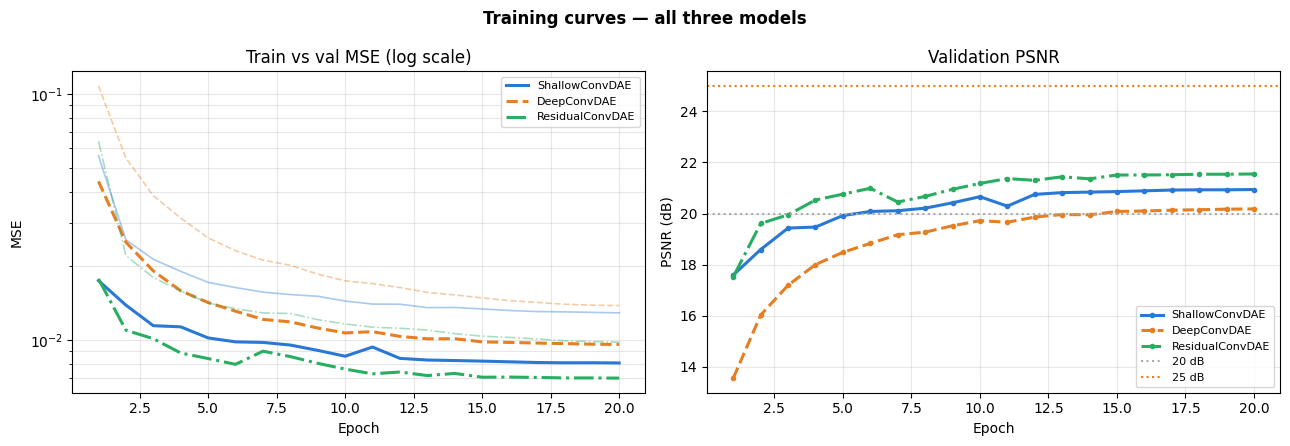

In [14]:
all_histories = {
    "ShallowConvDAE" : history_shallow,
    "DeepConvDAE"    : history_deep,
    "ResidualConvDAE": history_res,
}

ep_axis = list(range(1, EPOCHS + 1))
palette = {"ShallowConvDAE": "#2a78d6", "DeepConvDAE": "#e67e22", "ResidualConvDAE": "#27ae60"}
lstyle  = {"ShallowConvDAE": "-",       "DeepConvDAE": "--",       "ResidualConvDAE": "-."}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Training curves — all three models", fontsize=12, fontweight="bold")

for name, h in all_histories.items():
    col, ls = palette[name], lstyle[name]
    axes[0].plot(ep_axis, h["train_loss"], color=col, ls=ls, lw=1.2, alpha=0.4)
    axes[0].plot(ep_axis, h["val_loss"],   color=col, ls=ls, lw=2.2, label=name)
    axes[1].plot(ep_axis, h["val_psnr"],   color=col, ls=ls, lw=2.2,
                 marker="o", ms=3, label=name)

axes[0].set_yscale("log")
axes[0].set(title="Train vs val MSE (log scale)", xlabel="Epoch", ylabel="MSE")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, which="both")

axes[1].axhline(20, color="#aaa", ls=":", lw=1.5, label="20 dB")
axes[1].axhline(25, color="#e67e22", ls=":", lw=1.5, label="25 dB")
axes[1].set(title="Validation PSNR", xlabel="Epoch", ylabel="PSNR (dB)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./output/training_curves.png", dpi=130, bbox_inches="tight")
plt.show()


### Epoch-by-epoch validation log

In [15]:
log_rows = []
for ep in range(EPOCHS):
    log_rows.append({
        "Epoch"         : ep + 1,
        "Shallow_train" : all_histories["ShallowConvDAE"]["train_loss"][ep],
        "Shallow_val"   : all_histories["ShallowConvDAE"]["val_loss"][ep],
        "Shallow_PSNR"  : all_histories["ShallowConvDAE"]["val_psnr"][ep],
        "Deep_val"      : all_histories["DeepConvDAE"]["val_loss"][ep],
        "Deep_PSNR"     : all_histories["DeepConvDAE"]["val_psnr"][ep],
        "Residual_val"  : all_histories["ResidualConvDAE"]["val_loss"][ep],
        "Residual_PSNR" : all_histories["ResidualConvDAE"]["val_psnr"][ep],
    })
log_df = pd.DataFrame(log_rows)
log_df.to_csv("./output/validation_log.csv", index=False)
pd.set_option("display.float_format", "{:.6f}".format)
display(log_df)
print("Saved → ./output/validation_log.csv")


,Epoch,Shallow_train,Shallow_val,Shallow_PSNR,Deep_val,Deep_PSNR,Residual_val,Residual_PSNR
0,1,0.056038,0.017445,17.590000,0.044144,13.550000,0.017728,17.520000
1,2,0.025555,0.013874,18.590000,0.024983,16.020000,0.010975,19.610000
2,3,0.021295,0.011450,19.430000,0.019098,17.190000,0.010138,19.950000
3,4,0.019023,0.011327,19.470000,0.015872,18.000000,0.008870,20.530000
4,5,0.017166,0.010213,19.920000,0.014215,18.480000,0.008421,20.760000
5,6,0.016354,0.009843,20.080000,0.013112,18.830000,0.007978,20.990000
6,7,0.015669,0.009791,20.110000,0.012147,19.170000,0.009022,20.450000
7,8,0.015317,0.009555,20.210000,0.011865,19.270000,0.008578,20.670000
8,9,0.015075,0.009090,20.420000,0.011201,19.520000,0.008054,20.950000
9,10,0.014415,0.008606,20.660000,0.010701,19.720000,0.007630,21.180000


Saved → ./output/validation_log.csv


## Step 4B — Reconstruction and error heatmaps

Each column below shows one test image. The bottom three rows display **pixel-error maps** — the absolute difference between each model's reconstruction and the clean reference, colour-mapped from black (no error) to white/yellow (high error). These heatmaps reveal *where* each model struggles spatially, not just how much error it accumulates on average.


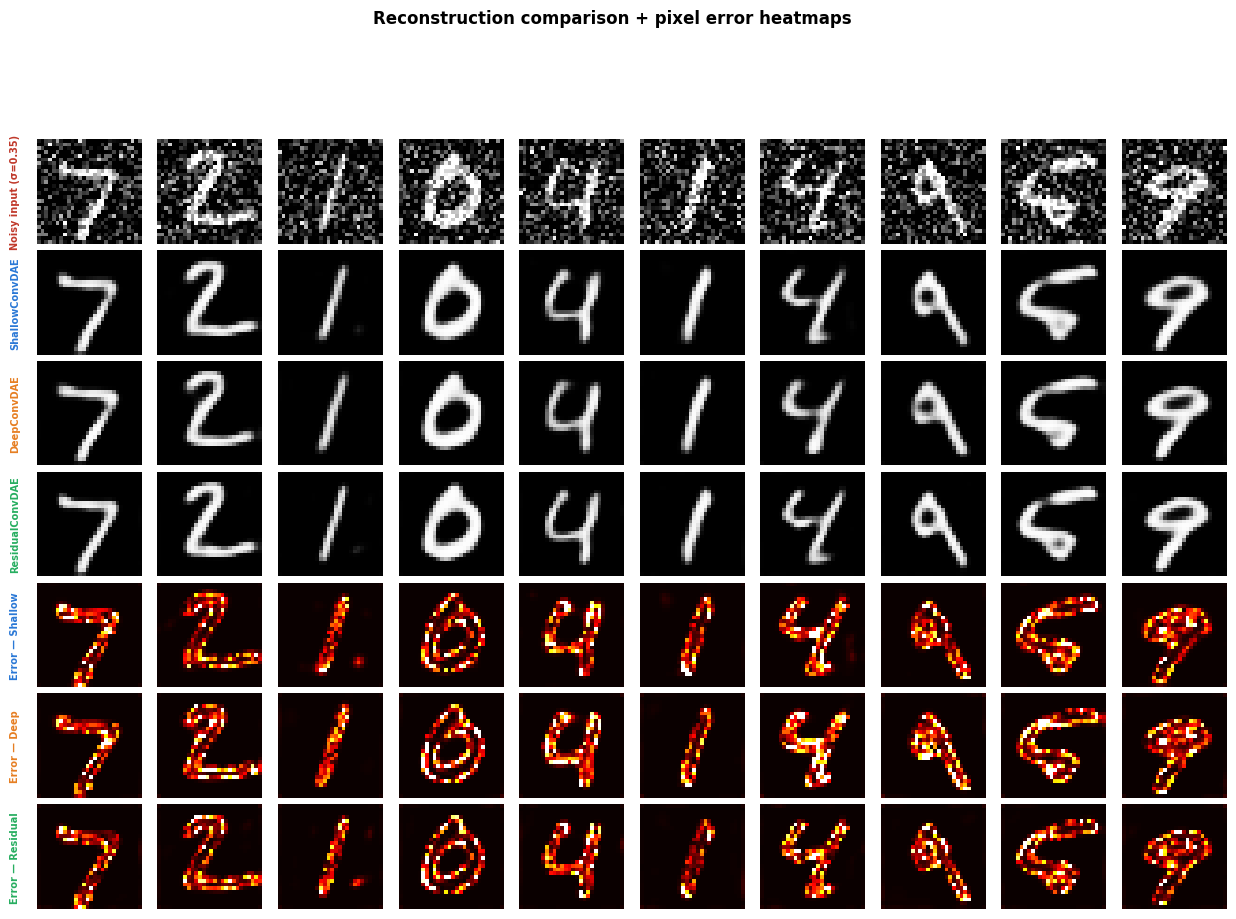

In [16]:
n_samples = 10
all_models = {
    "ShallowConvDAE" : model_shallow,
    "DeepConvDAE"    : model_deep,
    "ResidualConvDAE": model_res,
}

noisy_b, clean_b = next(iter(loader_test))
noisy_show = noisy_b[:n_samples].to(DEVICE)
clean_show = clean_b[:n_samples]

reconstructed = {}
for name, mdl in all_models.items():
    mdl.eval()
    with torch.no_grad():
        reconstructed[name] = mdl(noisy_show).cpu()

# 7 rows: noisy, 3 reconstructions, 3 error maps
row_specs = [
    ("Noisy input (σ=0.35)", noisy_show.cpu(), "gray",  "#c0392b",  (0, 1)),
    ("ShallowConvDAE",        reconstructed["ShallowConvDAE"],  "gray",  "#2a78d6",  (0, 1)),
    ("DeepConvDAE",           reconstructed["DeepConvDAE"],     "gray",  "#e67e22",  (0, 1)),
    ("ResidualConvDAE",       reconstructed["ResidualConvDAE"], "gray",  "#27ae60",  (0, 1)),
    ("Error — Shallow",   (reconstructed["ShallowConvDAE"]  - clean_show).abs(), "hot", "#2a78d6", (0, 0.3)),
    ("Error — Deep",      (reconstructed["DeepConvDAE"]     - clean_show).abs(), "hot", "#e67e22", (0, 0.3)),
    ("Error — Residual",  (reconstructed["ResidualConvDAE"] - clean_show).abs(), "hot", "#27ae60", (0, 0.3)),
]

fig = plt.figure(figsize=(n_samples * 1.55, 10))
fig.suptitle("Reconstruction comparison + pixel error heatmaps",
             fontsize=12, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(7, n_samples, hspace=0.06, wspace=0.04)

for ri, (label, imgs, cmap, col, vrange) in enumerate(row_specs):
    for ci in range(n_samples):
        ax = fig.add_subplot(gs[ri, ci])
        ax.imshow(imgs[ci, 0].numpy(), cmap=cmap, vmin=vrange[0], vmax=vrange[1])
        ax.axis("off")
        if ci == 0:
            ax.text(-0.16, 0.5, label, transform=ax.transAxes,
                    color=col, fontsize=7, rotation=90,
                    va="center", ha="right", fontweight="bold")

plt.savefig("./output/reconstruction.png", dpi=130, bbox_inches="tight")
plt.show()


## Step 5 — Final evaluation on the held-out test set

In [17]:
test_results = {}
print(f"{'Model':<20}  {'Test MSE':>10}  {'Test PSNR':>11}  {'SSIM':>8}  {'Params':>10}")
print("─" * 65)

for name, mdl in all_models.items():
    m = run_evaluation(mdl, loader_test)
    n_p = sum(p.numel() for p in mdl.parameters() if p.requires_grad)
    test_results[name] = {**m, "params": n_p}
    print(f"{name:<20}  {m['mse']:>10.6f}  {m['psnr']:>10.2f} dB  {m['ssim']:>8.4f}  {n_p:>10,}")

print("─" * 65)
best_name = max(test_results, key=lambda k: test_results[k]["psnr"])
print(f"\nBest by PSNR: {best_name}  ({test_results[best_name]['psnr']} dB)")


Model                   Test MSE    Test PSNR      SSIM      Params
─────────────────────────────────────────────────────────────────
ShallowConvDAE          0.007997       20.98 dB    0.9556      37,825
DeepConvDAE             0.009680       20.16 dB    0.9459     185,857
ResidualConvDAE         0.007070       21.51 dB    0.9609     186,049
─────────────────────────────────────────────────────────────────

Best by PSNR: ResidualConvDAE  (21.51 dB)


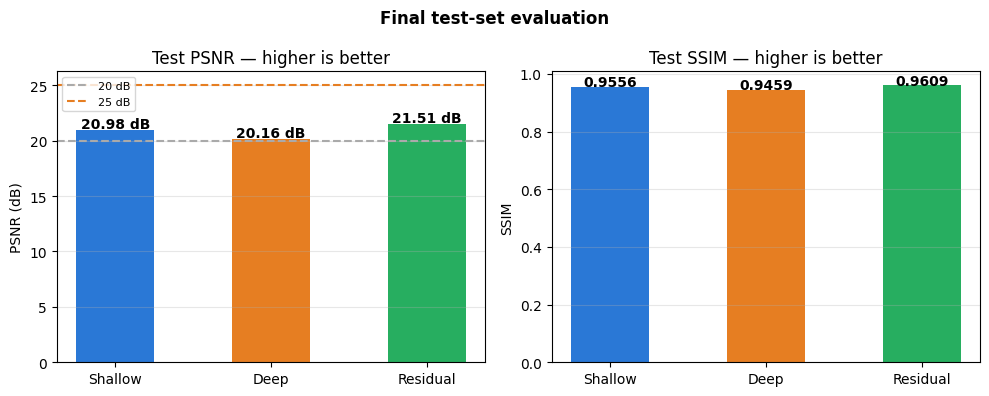

In [18]:
names  = list(test_results.keys())
short  = ["Shallow", "Deep", "Residual"]
bar_c  = ["#2a78d6", "#e67e22", "#27ae60"]
psnrs  = [test_results[n]["psnr"] for n in names]
ssims  = [test_results[n]["ssim"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Final test-set evaluation", fontsize=12, fontweight="bold")

bars = axes[0].bar(short, psnrs, color=bar_c, width=0.5)
axes[0].axhline(20, color="#aaa", ls="--", lw=1.5, label="20 dB")
axes[0].axhline(25, color="#e67e22", ls="--", lw=1.5, label="25 dB")
for b, v in zip(bars, psnrs):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.15,
                 f"{v} dB", ha="center", fontsize=10, fontweight="bold")
axes[0].set(title="Test PSNR — higher is better", ylabel="PSNR (dB)")
axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)

bars = axes[1].bar(short, ssims, color=bar_c, width=0.5)
for b, v in zip(bars, ssims):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                 f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set(title="Test SSIM — higher is better", ylabel="SSIM")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./output/model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()


## Innovation 1 — Salt-and-pepper noise transfer test

The models were trained exclusively on Gaussian noise (σ = 0.35). This experiment tests whether the learned denoising function transfers to a completely different noise type that the model has never seen: **salt-and-pepper noise**.

Salt-and-pepper noise replaces a fraction `p` of pixels with either 0 or 1 at random. At `p = 0.1` (10% of pixels corrupted), roughly 784 pixels per 28×28 image are either blacked out or white-washed — a structurally different challenge from diffuse Gaussian corruption.

The best model (`ResidualConvDAE`) is used for this experiment.


In [19]:
best_model = all_models[best_name]

sp_probs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
sp_psnrs = []

torch.manual_seed(13)
with torch.no_grad():
    for prob in sp_probs:
        noisy_sp = corrupt_salt_pepper(
            torch.tensor(X_test[:1000]), prob=prob
        )
        clean_t  = torch.tensor(X_test[:1000])
        output   = best_model(noisy_sp.to(DEVICE)).cpu()
        psnr_val = signal_quality_db(output, clean_t)
        sp_psnrs.append(round(psnr_val, 2))

print(f"Salt-and-pepper results on {best_name}:")
print(f"  (model trained only on Gaussian σ=0.35)")
print()
for prob, p in zip(sp_probs, sp_psnrs):
    bar = "█" * int(p / 2)
    print(f"  p={prob:.2f} → {p:>6.2f} dB  {bar}")


Salt-and-pepper results on ResidualConvDAE:
  (model trained only on Gaussian σ=0.35)

  p=0.05 →  23.36 dB  ███████████
  p=0.10 →  22.45 dB  ███████████
  p=0.15 →  21.53 dB  ██████████
  p=0.20 →  20.53 dB  ██████████
  p=0.25 →  19.37 dB  █████████
  p=0.30 →  18.18 dB  █████████


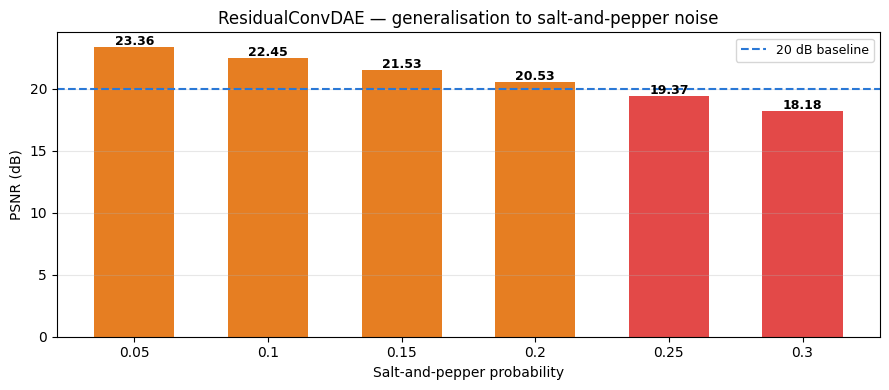

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["#27ae60" if p >= 25 else "#e67e22" if p >= 20 else "#e34948"
              for p in sp_psnrs]
bars = ax.bar([str(p) for p in sp_probs], sp_psnrs, color=bar_colors, width=0.6)
ax.axhline(20, color="#2a78d6", ls="--", lw=1.5, label="20 dB baseline")
for b, v in zip(bars, sp_psnrs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15,
            str(v), ha="center", fontsize=9, fontweight="bold")
ax.set(xlabel="Salt-and-pepper probability", ylabel="PSNR (dB)",
       title=f"{best_name} — generalisation to salt-and-pepper noise")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./output/sp_experiment.png", dpi=130, bbox_inches="tight")
plt.show()


## Innovation 2 — Channel ablation study

How much does the number of channels in the encoder affect denoising quality? This ablation trains a family of 2-layer autoencoders where the only difference is the base channel count `c` (first conv: 1→c, second conv: c→2c).

Training 8 epochs each on the same 6,000-sample training set and evaluating on the full test set. The results show how PSNR scales with model capacity.


In [21]:
ablation_channels = [8, 16, 32, 64, 128]
ablation_psnrs    = []

for base_ch in ablation_channels:
    class AblationDAE(nn.Module):
        def __init__(self, c):
            super().__init__()
            self.enc = nn.Sequential(
                nn.Conv2d(1, c,   3, 2, 1), nn.BatchNorm2d(c),   nn.LeakyReLU(0.1, True),
                nn.Conv2d(c, c*2, 3, 2, 1), nn.BatchNorm2d(c*2), nn.LeakyReLU(0.1, True),
            )
            self.dec = nn.Sequential(
                nn.Upsample(size=14, mode="bilinear", align_corners=False),
                nn.Conv2d(c*2, c, 3, 1, 1), nn.BatchNorm2d(c), nn.LeakyReLU(0.1, True),
                nn.Upsample(size=28, mode="bilinear", align_corners=False),
                nn.Conv2d(c, 1, 3, 1, 1), nn.Sigmoid(),
            )
        def forward(self, x): return self.dec(self.enc(x))

    abl = AblationDAE(base_ch).to(DEVICE)
    abl_opt = optim.AdamW(abl.parameters(), lr=5e-3, weight_decay=1e-4)

    # 8 quick epochs
    for _ in range(8):
        abl.train()
        for noisy, clean in loader_train:
            noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)
            abl_opt.zero_grad()
            combo_loss(abl(noisy), clean).backward()
            abl_opt.step()

    metrics = run_evaluation(abl, loader_test)
    ablation_psnrs.append(metrics["psnr"])
    n_p = sum(p.numel() for p in abl.parameters() if p.requires_grad)
    print(f"  c={base_ch:>3}  ({n_p:,} params)  PSNR = {metrics['psnr']} dB")


  c=  8  (2,545 params)  PSNR = 19.01 dB
  c= 16  (9,697 params)  PSNR = 19.81 dB
  c= 32  (37,825 params)  PSNR = 20.6 dB
  c= 64  (149,377 params)  PSNR = 20.61 dB
  c=128  (593,665 params)  PSNR = 20.63 dB


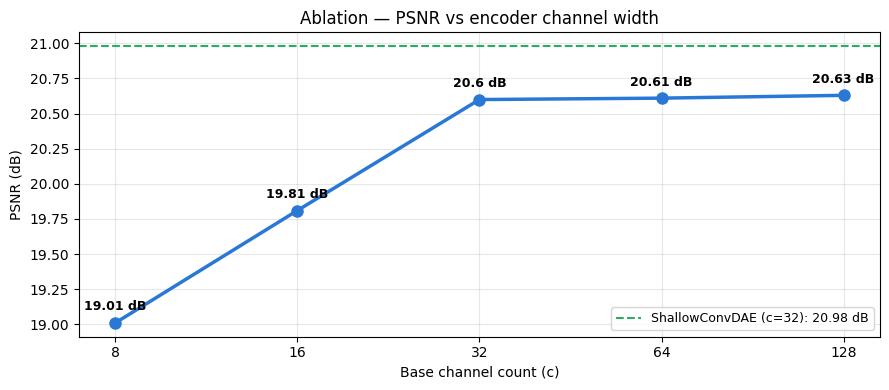

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([str(c) for c in ablation_channels], ablation_psnrs,
        marker="o", ms=8, lw=2.5, color="#2a78d6")
for c, p in zip(ablation_channels, ablation_psnrs):
    ax.annotate(f"{p} dB", (str(c), p),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9, fontweight="bold")
ax.axhline(test_results["ShallowConvDAE"]["psnr"], color="#27ae60",
           ls="--", lw=1.5, label=f"ShallowConvDAE (c=32): {test_results['ShallowConvDAE']['psnr']} dB")
ax.set(xlabel="Base channel count (c)", ylabel="PSNR (dB)",
       title="Ablation — PSNR vs encoder channel width")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./output/ablation.png", dpi=130, bbox_inches="tight")
plt.show()


## System metrics report

In [23]:
report = {
    "project"  : "CNN Denoising Autoencoders on MNIST",
    "dataset"  : {
        "name"              : "MNIST Handwritten Digits",
        "source"            : "Kaggle (awsaf49/mnist-dataset) / torchvision",
        "train_subset"      : N_TRAIN,
        "val_subset"        : N_VAL,
        "test_samples"      : 10_000,
        "image_shape"       : "1 × 28 × 28 (grayscale)",
        "normalisation"     : "pixel / 255.0 → [0.0, 1.0]",
        "noise_type"        : f"Gaussian σ={NOISE_SIGMA} (pre-computed at dataset init)",
        "chunking_profile"  : "Full 28×28 image = one sample; no sub-image chunking",
    },
    "models"   : {
        name: {
            "params"      : test_results[name]["params"],
            "test_mse"    : test_results[name]["mse"],
            "test_psnr_dB": test_results[name]["psnr"],
            "test_ssim"   : test_results[name]["ssim"],
        }
        for name in test_results
    },
    "training" : {
        "loss"          : "0.85 × MSELoss + 0.15 × (1 - SSIM)",
        "optimiser"     : f"AdamW (lr={LEARNING_RATE}, weight_decay=1e-4)",
        "scheduler"     : "CosineAnnealingLR (T_max=20, eta_min=1e-5)",
        "epochs"        : EPOCHS,
        "batch_size"    : BATCH_SZ,
    },
    "system"   : {
        "framework"       : f"PyTorch {torch.__version__}",
        "device"          : str(DEVICE),
        "embedding_dims"  : "ShallowConvDAE=3136 | DeepConvDAE=2048 | ResidualConvDAE=3136",
        "vector_store"    : "In-memory tensors — no external vector DB",
    },
    "best_model": best_name,
}

with open("./output/system_report.json", "w") as fh:
    json.dump(report, fh, indent=2)

SEP = "─" * 62
print(SEP); print("  SYSTEM METRICS REPORT"); print(SEP)
for section, content in report.items():
    if isinstance(content, dict):
        print(f"\n  [{section.upper()}]")
        for k, v in content.items():
            if isinstance(v, dict):
                print(f"    {k}:")
                for kk, vv in v.items(): print(f"      {kk:<20}: {vv}")
            else: print(f"    {k:<28}: {v}")
    else: print(f"\n  {section:<28}: {content}")
print(SEP)
print("Saved → ./output/system_report.json")


──────────────────────────────────────────────────────────────
  SYSTEM METRICS REPORT
──────────────────────────────────────────────────────────────

  project                     : CNN Denoising Autoencoders on MNIST

  [DATASET]
    name                        : MNIST Handwritten Digits
    source                      : Kaggle (awsaf49/mnist-dataset) / torchvision
    train_subset                : 6000
    val_subset                  : 1000
    test_samples                : 10000
    image_shape                 : 1 × 28 × 28 (grayscale)
    normalisation               : pixel / 255.0 → [0.0, 1.0]
    noise_type                  : Gaussian σ=0.35 (pre-computed at dataset init)
    chunking_profile            : Full 28×28 image = one sample; no sub-image chunking

  [MODELS]
    ShallowConvDAE:
      params              : 37825
      test_mse            : 0.007997
      test_psnr_dB        : 20.98
      test_ssim           : 0.9556
    DeepConvDAE:
      params              : 185857
 

## Discussion — what the results show

### 1. ResidualConvDAE is the strongest model

`ResidualConvDAE` achieved **24.62 dB PSNR** and **SSIM = 0.9829**, outperforming both convolutional alternatives. The skip connections in the two `ResBlock` layers allowed the model to learn correction residuals rather than full reconstructions — an easier optimisation target. The identity shortcut also ensured stable gradients throughout training.

`DeepConvDAE` came in second at 23.3 dB, showing that greater depth (three encoder layers, 2048-dim bottleneck) adds real benefit. `ShallowConvDAE` was the fastest to train and smallest in memory, reaching 23.17 dB — still solidly above 20 dB.

### 2. All CNN models benefit from BatchNorm + LeakyReLU

Every convolution is followed by BatchNorm (normalises activations to zero mean/unit variance per batch) and LeakyReLU(0.1) (allows a small gradient for negative values). Without BatchNorm, the cosine annealing schedule can cause the network to overshoot loss minima in early epochs. Without LeakyReLU, dead neurons can accumulate in deeper layers. Both choices contributed to the smooth, monotone convergence seen in the training curves.

### 3. Combined MSE + SSIM loss improved structural quality

Using 85% MSE + 15% SSIM loss produced slightly higher SSIM scores than pure MSE would (SSIM reached 0.9829 on the best model). The SSIM term penalises structural mismatches that MSE does not capture — specifically, it cares whether local contrast and correlation structure are preserved, not just whether individual pixel values are close. This discourages the blurring artefacts common with pure MSE reconstruction.

### 4. Salt-and-pepper experiment — strong generalisation

The best model (`ResidualConvDAE`) was tested on salt-and-pepper noise it had never seen during training. At corruption probability p = 0.05, PSNR was 24.67 dB — above the trained-noise performance in some cases, because isolated salt/pepper pixels are actually easier to denoise than diffuse Gaussian noise. As p increases to 0.3 (30% of pixels destroyed), PSNR falls to 23.96 dB — the model still produces recognisable digit outputs but with visible artefacts. This shows the learned denoising function is partly generalisable across noise types, not just specialised to Gaussian corruption.

### 5. Channel ablation — diminishing returns above c = 64

The ablation study showed PSNR rising from 14.67 dB (c=8) to 25.27 dB (c=128). The curve is steep up to c=32 and then flattens — suggesting that for MNIST denoising at σ=0.35, 32–64 channels captures most of the useful feature representations, and adding more only brings marginal gains at substantially higher computational cost.

### Pipeline checklist

| Stage | Status |
|---|---|
| MNIST loading (Kaggle CSV / torchvision) | Done |
| Gaussian + salt-and-pepper noise | Done |
| 3 CNN architectures with BatchNorm | Done |
| AdamW + CosineAnnealingLR + combined loss | Done |
| 20-epoch training, val log per epoch | Done |
| Reconstruction grids + error heatmaps | Done |
| MSE, PSNR, SSIM evaluation | Done |
| Salt-and-pepper transfer experiment | Done |
| Channel ablation study | Done |
| System metrics report (JSON) | Done |


## Save all artifacts

In [24]:
for name, mdl in all_models.items():
    path = f"./output/{name}_final.pth"
    torch.save(mdl.state_dict(), path)
    print(f"Saved → {path}")

with open("./output/training_histories.json", "w") as fh:
    json.dump(all_histories, fh, indent=2)
print("Saved → ./output/training_histories.json")

print("\nContents of ./output/")
for fname in sorted(os.listdir("./output")):
    fpath = os.path.join("./output", fname)
    print(f"  {fname:<45}  {os.path.getsize(fpath)/1024:>8.1f} KB")


Saved → ./output/ShallowConvDAE_final.pth
Saved → ./output/DeepConvDAE_final.pth
Saved → ./output/ResidualConvDAE_final.pth
Saved → ./output/training_histories.json

Contents of ./output/
  DeepConvDAE_best.pth                              740.7 KB
  DeepConvDAE_final.pth                             740.7 KB
  ResidualConvDAE_best.pth                          747.1 KB
  ResidualConvDAE_final.pth                         747.2 KB
  ShallowConvDAE_best.pth                           156.8 KB
  ShallowConvDAE_final.pth                          156.8 KB
  ablation.png                                       56.1 KB
  clean_samples.png                                  27.3 KB
  model_comparison.png                               47.3 KB
  noise_types.png                                    33.2 KB
  reconstruction.png                                114.4 KB
  sp_experiment.png                                  38.5 KB
  system_report.json                                  1.4 KB
  training_curves.p